# 02 — Classifiers for 5-HT2A activity

Three base classifiers plus a soft-voting ensemble, all evaluated on a
held-out **scaffold split**:

1. **Random Forest** on Morgan ECFP4
2. **XGBoost** on Morgan ECFP4 + RDKit descriptors
3. **kNN (Jaccard / Tanimoto)** on Morgan ECFP4
4. **Ensemble** — mean of the three predicted probabilities

All three base models are Optuna-tuned with the same 5-fold scaffold-grouped
CV. Conformal-prediction uncertainty / applicability domain is layered on
top of the saved models in NB3.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import (AllChem, Descriptors, Crippen, rdMolDescriptors, QED,
                         Draw)
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.DataStructs import ConvertToNumpyArray
RDLogger.DisableLog("rdApp.*")

USER_DIR = Path.cwd().resolve()
PROC = USER_DIR / "data" / "processed"
RANDOM_STATE = 42
N_BITS = 2048

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

In [2]:
df = pd.read_parquet(PROC / "5ht2a_modeling.parquet")
print(f"Loaded {len(df):,} compounds, {df['active'].mean():.1%} active")

Loaded 3,329 compounds, 53.4% active


## Fingerprint and descriptor calculation

In [3]:
def morgan_fp_array(smi, radius=2, n_bits=N_BITS):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    ConvertToNumpyArray(fp, arr)
    return arr

DESCRIPTORS = {
    "MW":         Descriptors.MolWt,
    "LogP":       Crippen.MolLogP,
    "TPSA":       Descriptors.TPSA,
    "HBD":        rdMolDescriptors.CalcNumHBD,
    "HBA":        rdMolDescriptors.CalcNumHBA,
    "RotB":       rdMolDescriptors.CalcNumRotatableBonds,
    "NAromRings": rdMolDescriptors.CalcNumAromaticRings,
    "FracCSP3":   rdMolDescriptors.CalcFractionCSP3,
    "QED":        QED.qed,
    "HeavyAtoms": Descriptors.HeavyAtomCount,
    "NRings":     rdMolDescriptors.CalcNumRings,
    "FormalCharge": Chem.rdmolops.GetFormalCharge,
}

def calc_descs(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    return np.array([fn(m) for fn in DESCRIPTORS.values()], dtype=np.float32)

fps   = [morgan_fp_array(s) for s in df["smiles_std"]]
descs = [calc_descs(s)      for s in df["smiles_std"]]
keep  = [(f is not None) and (d is not None) for f, d in zip(fps, descs)]

df = df.loc[keep].reset_index(drop=True)
X_fp   = np.stack([f for f, k in zip(fps, keep)   if k])
X_desc = np.stack([d for d, k in zip(descs, keep) if k])
X_comb = np.hstack([X_fp, X_desc]).astype(np.float32)
X_fp_bool = X_fp.astype(bool)            # kNN-Jaccard wants bool input
y = df["active"].values
print(f"FP {X_fp.shape}, desc {X_desc.shape}, combined {X_comb.shape}")

FP (3329, 2048), desc (3329, 12), combined (3329, 2060)


## Scaffold split

In [4]:
def scaffold_of(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return ""
    s = MurckoScaffold.GetScaffoldForMol(m)
    return Chem.MolToSmiles(s) if s.GetNumAtoms() else smi

df["scaffold"] = df["smiles_std"].map(scaffold_of)
print(f"Unique scaffolds: {df['scaffold'].nunique():,} / {len(df):,}")

def scaffold_split_indices(scaffolds, test_size=0.2, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    sc_to_idx = {}
    for i, s in enumerate(scaffolds):
        sc_to_idx.setdefault(s, []).append(i)
    groups = list(sc_to_idx.values()); rng.shuffle(groups)
    n_train_target = int((1 - test_size) * len(scaffolds))
    tr, te = [], []
    for g in groups:
        (tr if len(tr) + len(g) <= n_train_target else te).extend(g)
    return np.array(tr), np.array(te)

train_idx, test_idx = scaffold_split_indices(df["scaffold"].values, test_size=0.2)
print(f"Train: {len(train_idx):,} ({y[train_idx].mean():.1%} active)")
print(f"Test : {len(test_idx):,} ({y[test_idx].mean():.1%} active)")

Unique scaffolds: 1,352 / 3,329
Train: 2,663 (52.7% active)
Test : 666 (56.0% active)


In [5]:
from sklearn.model_selection import GroupKFold
group_kfold = GroupKFold(n_splits=5)
train_scaffolds = df["scaffold"].values[train_idx]
CV_FOLDS = list(group_kfold.split(np.zeros(len(train_idx)), y[train_idx],
                                    train_scaffolds))

## Optuna setup and model training

In [6]:
# Each entry: how to suggest hyperparameters, which model class to instantiate,
# which feature matrix to use, and how many Optuna trials to spend.
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

def rf_params(trial):
    return dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 800, step=100),
        max_depth         = trial.suggest_int("max_depth", 6, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features      = trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.1, 0.2]),
        class_weight      = trial.suggest_categorical("class_weight", [None, "balanced"]),
        n_jobs=-1, random_state=RANDOM_STATE,
    )

def xgb_params(trial):
    return dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 1000, step=100),
        max_depth        = trial.suggest_int("max_depth", 3, 12),
        learning_rate    = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        gamma            = trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, eval_metric="auc",
    )

def knn_params(trial):
    return dict(
        n_neighbors = trial.suggest_int("n_neighbors", 3, 25),
        weights     = trial.suggest_categorical("weights", ["uniform", "distance"]),
        metric="jaccard", algorithm="brute", n_jobs=-1,
    )

MODELS = {
    "RF":  dict(cls=RandomForestClassifier, params_fn=rf_params,
                X=X_fp,      n_trials=40, label="RF (ECFP4)"),
    "XGB": dict(cls=XGBClassifier,          params_fn=xgb_params,
                X=X_comb,    n_trials=60, label="XGB (ECFP4 + desc)"),
    "KNN": dict(cls=KNeighborsClassifier,   params_fn=knn_params,
                X=X_fp_bool, n_trials=20, label="kNN (Jaccard, ECFP4)"),
}

In [7]:
from sklearn.metrics import roc_auc_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(cls, params_fn, X):
    """Build an objective that runs 5-fold scaffold-CV on (X, y)[train_idx]."""
    def objective(trial):
        params = params_fn(trial)
        Xt, yt = X[train_idx], y[train_idx]
        scores = []
        for tr, va in CV_FOLDS:
            m = cls(**params).fit(Xt[tr], yt[tr])
            scores.append(roc_auc_score(yt[va], m.predict_proba(Xt[va])[:, 1]))
        return float(np.mean(scores))
    return objective

studies = {}
for name, cfg in MODELS.items():
    print(f"\n▶ Tuning {name} ({cfg['n_trials']} trials)...")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(make_objective(cfg["cls"], cfg["params_fn"], cfg["X"]),
                   n_trials=cfg["n_trials"], show_progress_bar=True)
    studies[name] = study
    print(f"  best CV ROC-AUC: {study.best_value:.4f}")
    print(f"  best params: {study.best_params}")


▶ Tuning RF (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]

  best CV ROC-AUC: 0.8682
  best params: {'n_estimators': 600, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.1, 'class_weight': None}

▶ Tuning XGB (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

  best CV ROC-AUC: 0.8699
  best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.07709562636847037, 'subsample': 0.9612434731543275, 'colsample_bytree': 0.7355464678002215, 'min_child_weight': 2, 'reg_alpha': 3.655809596610483e-05, 'reg_lambda': 6.966690307599097e-06, 'gamma': 0.2677006699302943}

▶ Tuning KNN (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

  best CV ROC-AUC: 0.8502
  best params: {'n_neighbors': 22, 'weights': 'distance'}


## Prediction and model evaluation

In [8]:
from sklearn.metrics import (matthews_corrcoef, balanced_accuracy_score,
                              accuracy_score, f1_score, confusion_matrix,
                              roc_curve, average_precision_score)

trained = {}
test_proba = {}
for name, cfg in MODELS.items():
    params = studies[name].best_params

    if name == "KNN":
        params = {**params, "metric": "jaccard", "algorithm": "brute", "n_jobs": -1}
    elif name == "RF":
        params = {**params, "n_jobs": -1, "random_state": RANDOM_STATE}
    elif name == "XGB":
        params = {**params, "tree_method": "hist", "n_jobs": -1,
                  "random_state": RANDOM_STATE, "eval_metric": "auc"}
    model = cfg["cls"](**params).fit(cfg["X"][train_idx], y[train_idx])
    trained[name] = model
    test_proba[name] = model.predict_proba(cfg["X"][test_idx])[:, 1]
    print(f"{name} fitted.")

# Ensemble = mean of probabilities
test_proba["Ensemble"] = np.mean(list(test_proba.values()), axis=0)

RF fitted.
XGB fitted.
KNN fitted.


In [9]:
def metrics_for(proba, y_true):
    pred = (proba >= 0.5).astype(int)
    return {
        "ROC-AUC":  roc_auc_score(y_true, proba),
        "PRC-AUC":  average_precision_score(y_true, proba),
        "Bal Acc":  balanced_accuracy_score(y_true, pred),
        "MCC":      matthews_corrcoef(y_true, pred),
        "F1":       f1_score(y_true, pred),
        "Acc":      accuracy_score(y_true, pred),
    }

results = pd.DataFrame({
    (MODELS[n]["label"] if n in MODELS else "Ensemble (mean)"):
        metrics_for(p, y[test_idx])
    for n, p in test_proba.items()
}).T.round(3)

print("\nHeld-out test (scaffold split):")
print(results)


Held-out test (scaffold split):
                      ROC-AUC  PRC-AUC  Bal Acc    MCC     F1    Acc
RF (ECFP4)              0.869    0.890    0.777  0.556  0.761  0.764
XGB (ECFP4 + desc)      0.871    0.897    0.796  0.588  0.802  0.791
kNN (Jaccard, ECFP4)    0.880    0.901    0.783  0.561  0.789  0.778
Ensemble (mean)         0.889    0.906    0.812  0.620  0.809  0.803


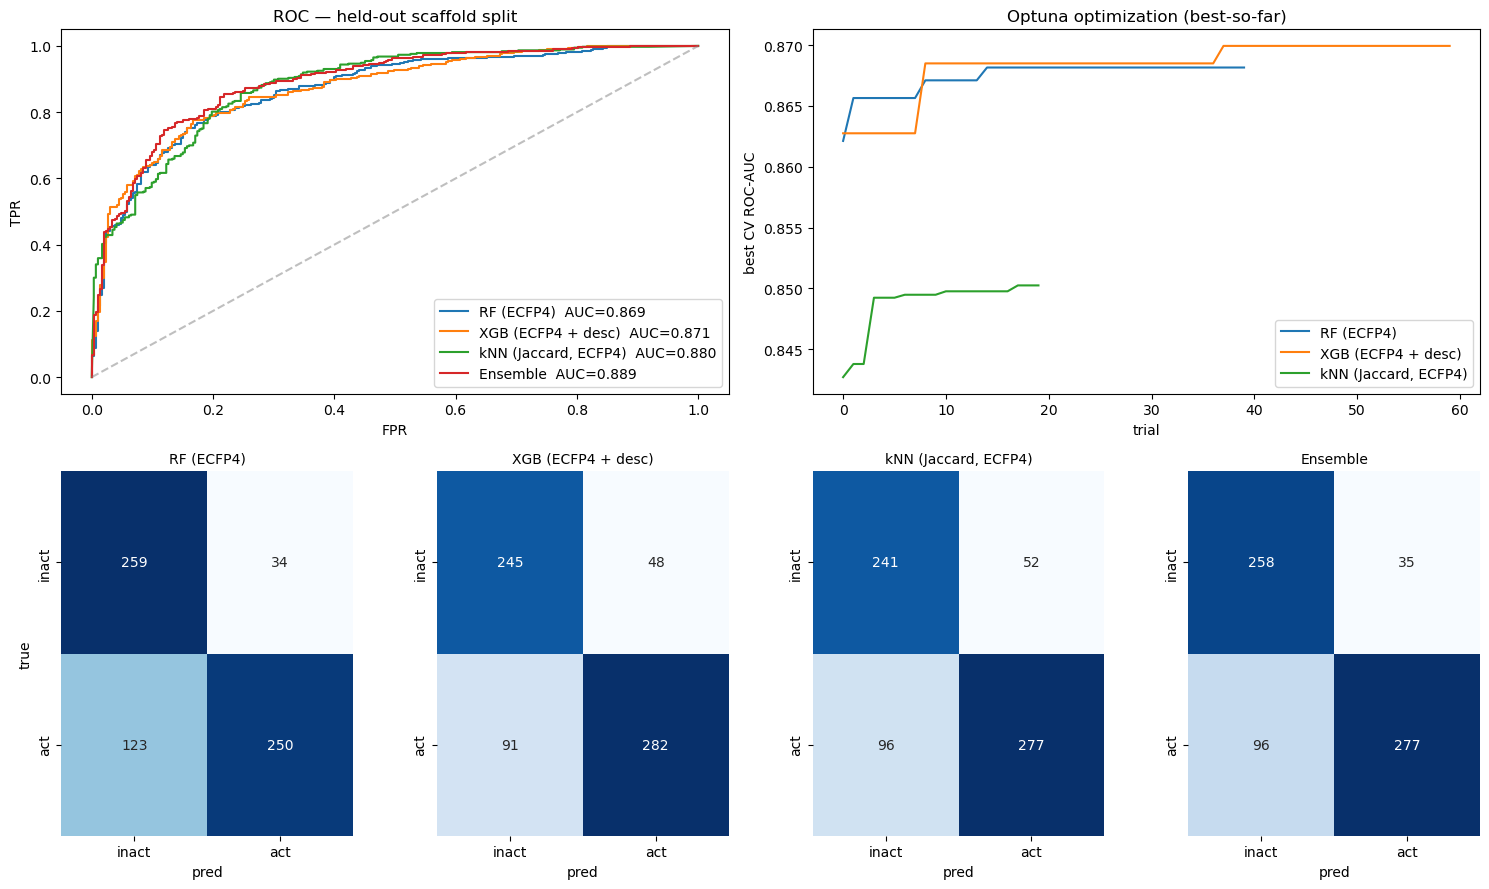

In [10]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1])

# ROC panel (spans top two columns)
ax_roc = fig.add_subplot(gs[0, :2])
colors = {"RF": "C0", "XGB": "C1", "KNN": "C2", "Ensemble": "C3"}
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y[test_idx], proba)
    auc = roc_auc_score(y[test_idx], proba)
    label = MODELS[name]["label"] if name in MODELS else "Ensemble"
    ax_roc.plot(fpr, tpr, color=colors[name], label=f"{label}  AUC={auc:.3f}")
ax_roc.plot([0, 1], [0, 1], "--", color="grey", alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC — held-out scaffold split"); ax_roc.legend(loc="lower right")

# Optimization-history panel
ax_hist = fig.add_subplot(gs[0, 2:])
for name, study in studies.items():
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.maximum.accumulate(vals)
    ax_hist.plot(best, "-", color=colors[name], label=MODELS[name]["label"])
ax_hist.set_xlabel("trial"); ax_hist.set_ylabel("best CV ROC-AUC")
ax_hist.set_title("Optuna optimization (best-so-far)"); ax_hist.legend()

# Confusion matrices (one per model + ensemble)
for i, (name, proba) in enumerate(test_proba.items()):
    ax = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y[test_idx], (proba >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["inact", "act"], yticklabels=["inact", "act"],
                cbar=False)
    title = MODELS[name]["label"] if name in MODELS else "Ensemble"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("pred"); ax.set_ylabel("true" if i == 0 else "")

fig.tight_layout()
fig.savefig(PROC / "viz_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


Top disagreements across base models:
                                                         smiles_std  active  \
2508                      O=C(Nc1[nH]ncc1Br)N1CCN(CCc2ccc(F)cc2)CC1       1   
1389  COc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CCNS(=O)(=O)c2ccc(N)c(Br)c2)CC1       0   
1845                          Fc1ccc(OCCCN2CCC(c3ccc(Cl)cc3)CC2)cc1       0   
3251                          COc1ccc(-c2nc(C3CCCC3)nc3c2CCNCC3)cc1       1   
1463                                       CC1CNCCc2c(Cl)cc(Cl)cc21       0   
959                COc1ccccc1N1CCN(CCCC(=O)Nc2ccn3ncc(C=NO)c3c2)CC1       0   

      rf_proba  xgb_proba  knn_proba  ensemble_proba  disagree_range  \
2508     0.728      0.272      0.855           0.619           0.583   
1389     0.309      0.291      0.861           0.487           0.569   
1845     0.368      0.255      0.802           0.475           0.547   
3251     0.308      0.656      0.826           0.597           0.518   
1463     0.348      0.700      0.184           

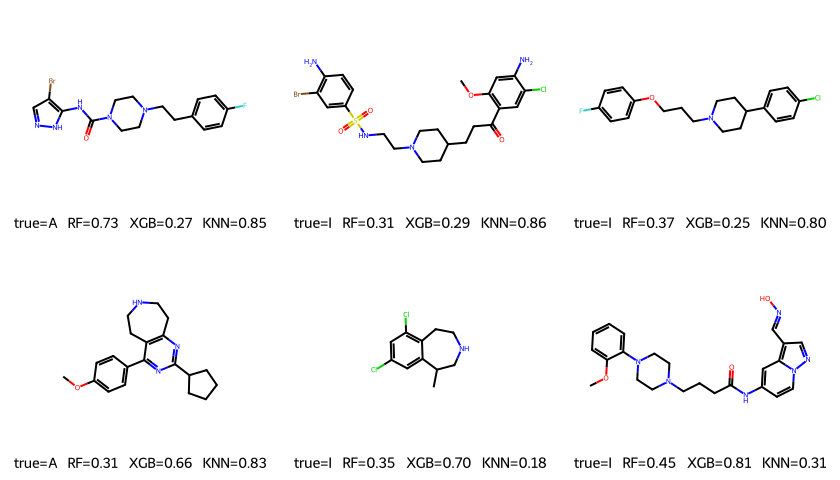

In [11]:
test_df = df.iloc[test_idx].copy()
for name in MODELS:
    test_df[f"{name.lower()}_proba"] = test_proba[name]
test_df["ensemble_proba"] = test_proba["Ensemble"]

base_proba_cols = [f"{n.lower()}_proba" for n in MODELS]
test_df["disagree_range"] = (
    test_df[base_proba_cols].max(axis=1) - test_df[base_proba_cols].min(axis=1)
)

top_disagree = test_df.nlargest(6, "disagree_range")[
    ["smiles_std", "active", *base_proba_cols, "ensemble_proba",
     "disagree_range", "pchembl_value_Mean"]
].round(3)
print("\nTop disagreements across base models:")
print(top_disagree)

mols = [Chem.MolFromSmiles(s) for s in top_disagree["smiles_std"]]
legends = [
    f"true={'A' if a else 'I'}  RF={r:.2f}  XGB={x:.2f}  KNN={k:.2f}"
    for a, r, x, k in zip(top_disagree["active"], top_disagree["rf_proba"],
                          top_disagree["xgb_proba"], top_disagree["knn_proba"])
]
Draw.MolsToGridImage(mols, legends=legends, molsPerRow=3, subImgSize=(280, 240))

In [12]:
import joblib
joblib.dump({
    "models": trained,
    "best_params": {n: studies[n].best_params for n in MODELS},
    "model_feature_keys": {  # which feature matrix each model expects
        "RF": "fp", "XGB": "comb", "KNN": "fp_bool",
    },
    "descriptors": list(DESCRIPTORS),
    "n_bits": N_BITS,
    "fp_radius": 2,
    "metrics": results.to_dict(),
    "train_inchikeys": df.iloc[train_idx]["inchikey"].tolist(),
    "train_actives_smiles": df.iloc[train_idx].query("active == 1")["smiles_std"].tolist(),
}, PROC / "models.joblib")
print(f"Saved models bundle: {(PROC / 'models.joblib').stat().st_size / 1e6:.1f} MB")

Saved models bundle: 24.6 MB
